In [1]:
import pandas as pd
import numpy as np

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import plotly.graph_objects as go

In [6]:
from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
path =  r'C:\Users\linas\OneDrive\Documents\PROJECT\elektros_suvartojimas\\'

In [7]:
df = pd.read_csv(path + 'Valandiniai[2026-06 - 2026-08].csv', sep=';')

In [11]:
df['datetime'] = pd.to_datetime(df['Data, valanda']).dt.tz_localize(None)

In [12]:
df['volume']= df['Kiekis, kWh']

In [13]:
df

,Vartotojo kodas,Objekto nr.,Asmens / įmonės kodas,Asmens vardas pavardė / įmonės pavadinimas,Objekto pavadinimas,Objekto tipas,Objekto adresas,"Leistinoji galia, kW",Viso skaitiklių,Skaitiklio nr.,"Data, valanda",Energijos tipas,Suvartojimas,"Kiekis, kWh",datetime,volume
0,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-06-01T00:00:00+03:00,P+,Faktinis,0.328,2026-06-01 00:00:00,0.328
1,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-06-01T00:15:00+03:00,P+,Faktinis,0.224,2026-06-01 00:15:00,0.224
2,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-06-01T00:30:00+03:00,P+,Faktinis,0.108,2026-06-01 00:30:00,0.108
3,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-06-01T00:45:00+03:00,P+,Faktinis,0.126,2026-06-01 00:45:00,0.126
4,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-06-01T01:00:00+03:00,P+,Faktinis,0.117,2026-06-01 01:00:00,0.117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7291,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-08-15T22:45:00+03:00,P+,Faktinis,0.123,2026-08-15 22:45:00,0.123
7292,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-08-15T23:00:00+03:00,P+,Faktinis,0.110,2026-08-15 23:00:00,0.110
7293,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-08-15T23:15:00+03:00,P+,Faktinis,0.107,2026-08-15 23:15:00,0.107
7294,12024344,12205429,37905040509,LINAS RUDELIS,BUTAS,Butas,"Žozefo Pusjė g. 24-8, 14188 Vilnius",12,1,NaN,2026-08-15T23:30:00+03:00,P+,Faktinis,0.079,2026-08-15 23:30:00,0.079


In [18]:
def plot_daily_trend(df):
    """Bendra suvartojimo tendencija laike (sugrupuota po 1 parą)."""
    # Sukuriame laikiną kopiją su datetime indeksu, kad nesugadintume originalaus df
    temp_df = df.set_index('datetime').copy()
    daily_consumption = temp_df['volume'].resample('D').sum()
    
    plt.figure(figsize=(12, 5))
    plt.plot(daily_consumption.index, daily_consumption.values, color='tab:blue', marker='o', linestyle='-')
    plt.title('Paros elektros suvartojimo tendencija', fontsize=14, fontweight='bold')
    plt.xlabel('Data')
    plt.ylabel('Bendras suvartojimas')
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_hourly_profile(df):
    """Paros piko analizė – kuriomis valandomis suvartojama daugiausia."""
    temp_df = df.set_index('datetime').copy()
    hourly_profile = temp_df.groupby(temp_df.index.hour)['volume'].mean()
    
    plt.figure(figsize=(12, 5))
    plt.bar(hourly_profile.index, hourly_profile.values, color='tab:orange', alpha=0.8)
    plt.title('Vidutinis suvartojimas pagal paros valandas (Piko paieška)', fontsize=14, fontweight='bold')
    plt.xlabel('Paros valanda')
    plt.ylabel('Vidutinis suvartojimas')
    plt.xticks(range(0, 24))
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_weekly_profile(df):
    """Savaitės dienų analizė (Darbo dienos vs Savaitgaliai)."""
    temp_df = df.set_index('datetime').copy()
    weekly_profile = temp_df.groupby(temp_df.index.dayofweek)['volume'].mean()
    savaites_dienos = ['Pr', 'An', 'Tr', 'Kt', 'Pe', 'Še', 'Se']
    
    plt.figure(figsize=(10, 5))
    plt.bar(savaites_dienos, weekly_profile.values, color='tab:green', alpha=0.8)
    plt.title('Vidutinis suvartojimas pagal savaitės dienas', fontsize=14, fontweight='bold')
    plt.xlabel('Savaitės diena')
    plt.ylabel('Vidutinis suvartojimas')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_hourly_distribution(df):
    """15 min duomenų sklaidos (Boxplot) grafikas anomalijoms rasti."""
    temp_df = df.set_index('datetime').copy()
    
    plt.figure(figsize=(14, 6))
    sns.boxplot(x=temp_df.index.hour, y=temp_df['volume'], palette='coolwarm')
    plt.title('15 min suvartojimo sklaidos dėžutė (Boxplot) kiekvieną valandą', fontsize=14, fontweight='bold')
    plt.xlabel('Paros valanda')
    plt.ylabel('Suvartojimas (Volume)')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()


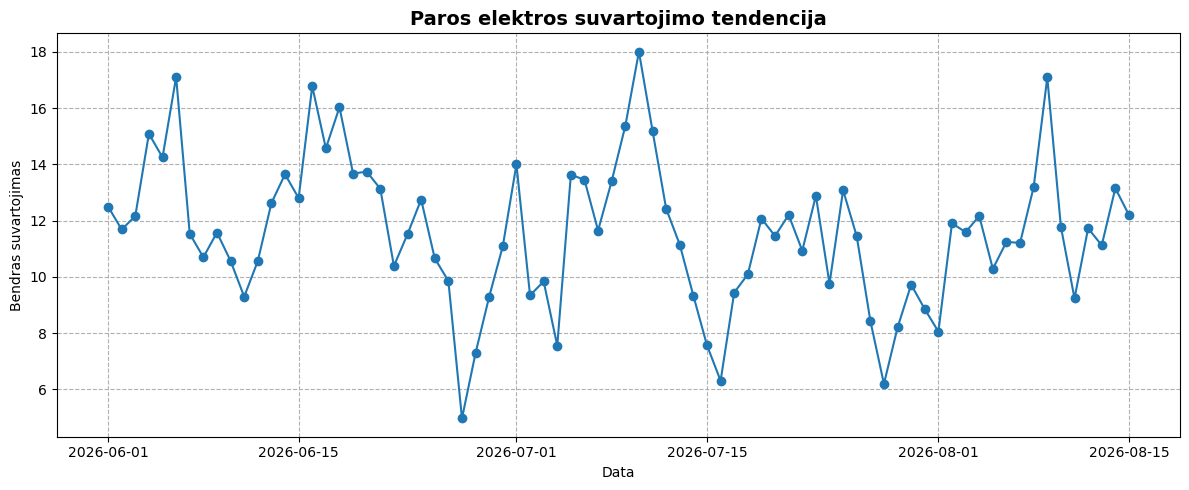

In [23]:
plot_daily_trend(df)

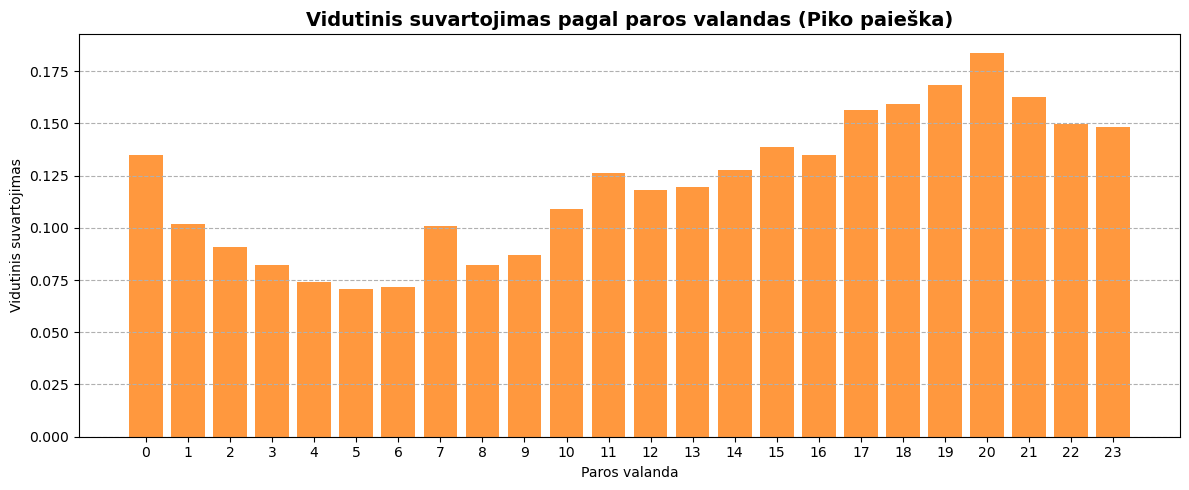

In [20]:
plot_hourly_profile(df)

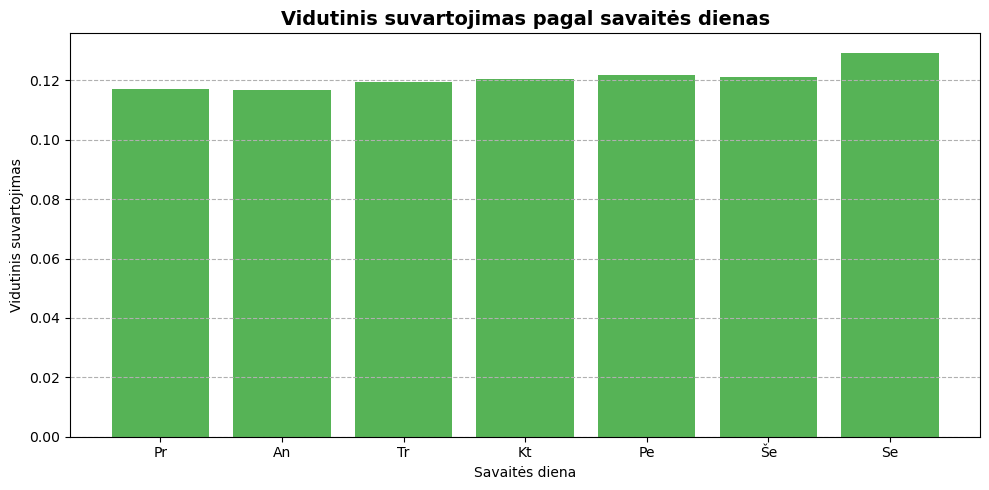

In [21]:
plot_weekly_profile(df)

C:\Users\linas\AppData\Local\Temp\ipykernel_23840\119399240.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=temp_df.index.hour, y=temp_df['volume'], palette='coolwarm')


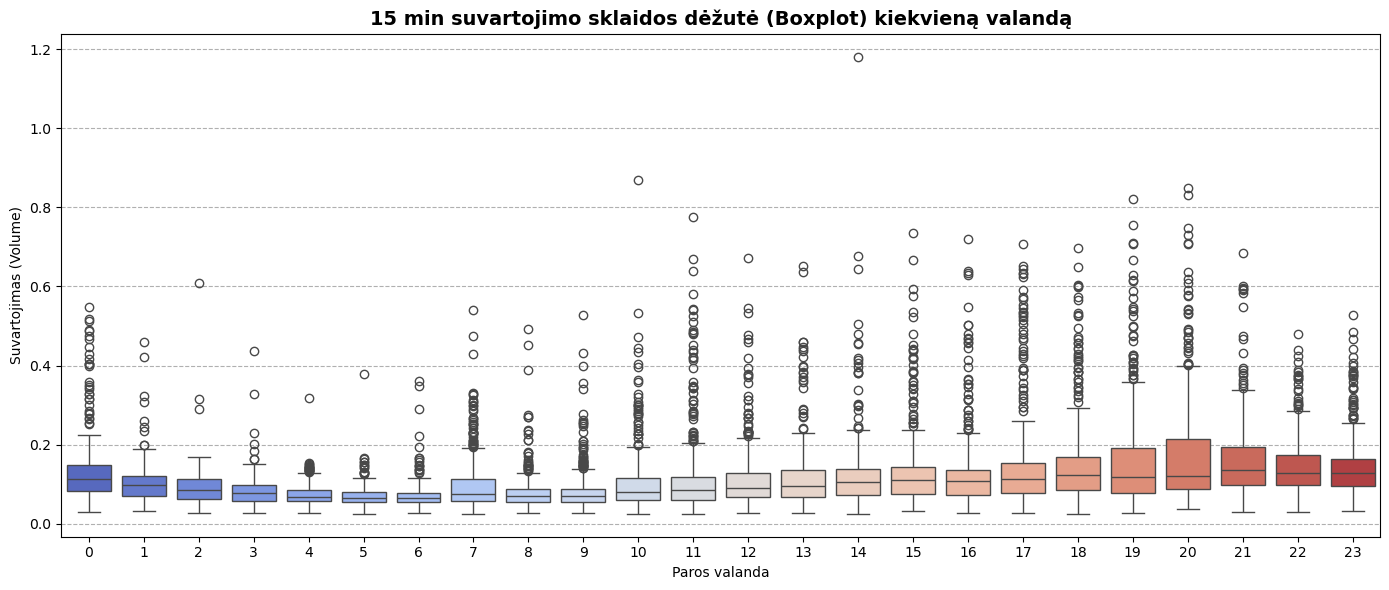

In [22]:
 plot_hourly_distribution(df)

In [35]:
import plotly.graph_objects as go
import pandas as pd

def plot_daily_trend(df, export_html=False, filename="daily_consumption_trend.html"):
    """
    Plots the daily electricity consumption trend using an interactive Plotly chart.
    
    Parameters:
        df (DataFrame): Input pandas DataFrame containing 'datetime' and 'volume' columns.
        export_html (bool): If True, exports the interactive chart to an HTML file.
        filename (str): Name of the exported HTML file if export_html is True.
    """
    # Create a temporary copy and set datetime as index
    temp_df = df.set_index('datetime').copy()
    
    # Resample to daily frequency and calculate the total sum
    daily_consumption = temp_df['volume'].resample('D').sum().reset_index()
    
    # Create the interactive interactive plot
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=daily_consumption['datetime'],
        y=daily_consumption['volume'],
        mode='lines+markers',
        name='Daily Volume',
        line=dict(color='#1f77b4', width=2),
        marker=dict(size=6),
        hovertemplate='<b>Date</b>: %{x|%Y-%m-%d}<br><b>Total Volume</b>: %{y:.2f}<extra></extra>'
    ))
    
    # Update layout details for high scannability and aesthetics
    fig.update_layout(
        title={
            'text': "Daily Electricity Consumption Trend",
            'y':0.95,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': dict(size=18, family="Arial", color="black")
        },
        xaxis_title="Date",
        yaxis_title="Total Consumption (Volume)",
        template="plotly_white",
        hovermode="x unified",
        width=950,
        height=500
    )
    
    # Add subtle gridlines
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightPink' if False else 'rgba(200,200,200,0.4)')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.4)')
    
    # Save to HTML file if requested
    if export_html:
        fig.write_html(filename)
        print(f"Interactive chart successfully exported to: {filename}")
        
    # Render the chart in Jupyter Notebook
    fig.show()


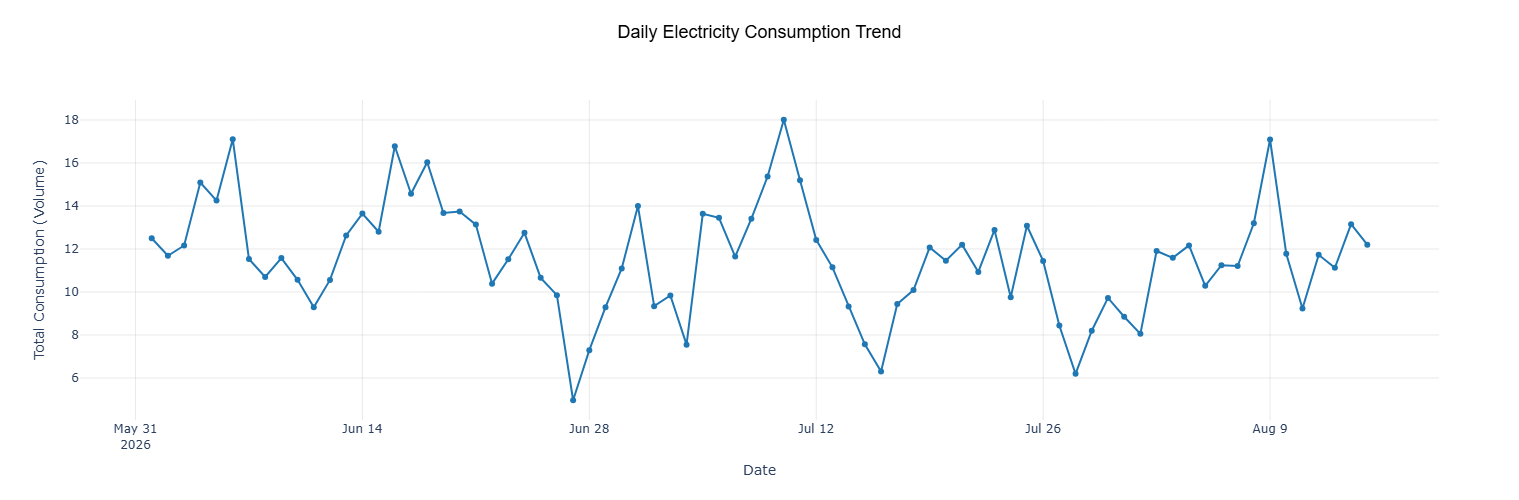

In [36]:
plot_daily_trend(df)

In [53]:
df[['datetime', 'volume']].head()

,datetime,volume
0,2026-06-01 00:00:00,0.328
1,2026-06-01 00:15:00,0.224
2,2026-06-01 00:30:00,0.108
3,2026-06-01 00:45:00,0.126
4,2026-06-01 01:00:00,0.117


In [54]:
import pandas as pd
import plotly.graph_objects as go

def plot_timeseries(df, export_html: str | None = None) -> go.Figure:
    """
    Full-period line chart of electricity volume consumption.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    export_html : optional path, e.g. 'timeseries.html' — if given, saves standalone HTML
    """
    df = df.sort_values('datetime')

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df['datetime'],
        y=df['volume'],
        mode='lines',
        name='Volume',
        line=dict(width=1, color='#2E86AB'),
        hovertemplate='%{x}<br>Volume: %{y:.3f}<extra></extra>'
    ))

    fig.update_layout(
        title='Electricity Volume Consumption Over Time',
        xaxis_title='Datetime',
        yaxis_title='Volume (kWh)',
        template='plotly_white',
        hovermode='x unified',
        xaxis=dict(rangeslider=dict(visible=True), type='date'),
        height=450
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

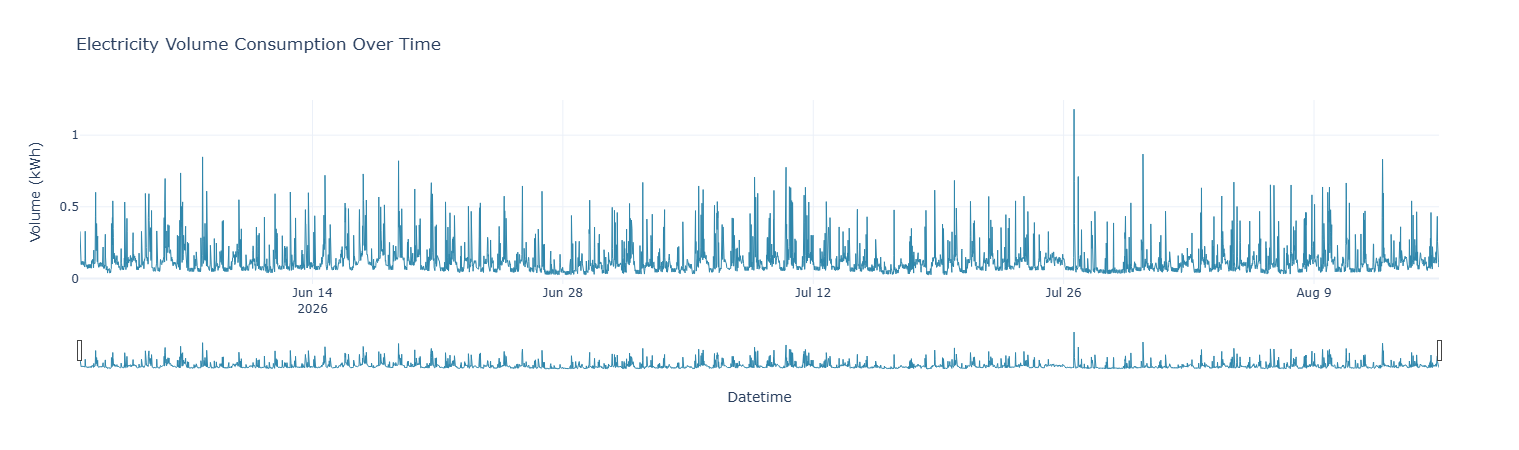

In [55]:
plot_timeseries(df) #, export_html='timeseries.html'

In [56]:
import pandas as pd
import plotly.graph_objects as go

# Map friendly labels to pandas resample rules
FREQ_MAP = {
    '15min': '15min',
    '30min': '30min',
    '1h': '1h',
    '1d': '1D',
    '1w': '1W',
    '1m': 'MS',   # month start
}

def plot_timeseries(df, freq: str = '15min', export_html: str | None = None) -> go.Figure:
    """
    Time series line chart of electricity volume consumption,
    resampled to the given frequency.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    freq : one of '15min', '30min', '1h', '1d', '1w', '1m'
    export_html : optional path, e.g. 'timeseries.html' — if given, saves standalone HTML
    """
    if freq not in FREQ_MAP:
        raise ValueError(f"freq must be one of {list(FREQ_MAP)}")

    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d = d.sort_values('datetime').set_index('datetime')

    rule = FREQ_MAP[freq]
    d = d['volume'].resample(rule).sum().reset_index()

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=d['datetime'],
        y=d['volume'],
        mode='lines',
        name='Volume',
        line=dict(width=1.3, color='#2E86AB'),
        hovertemplate='%{x}<br>Volume: %{y:.3f}<extra></extra>'
    ))

    fig.update_layout(
        title=f'Electricity Volume Consumption ({freq} resolution)',
        xaxis_title='Datetime',
        yaxis_title='Volume (kWh)',
        template='plotly_white',
        hovermode='x unified',
        xaxis=dict(rangeslider=dict(visible=True), type='date'),
        height=450
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

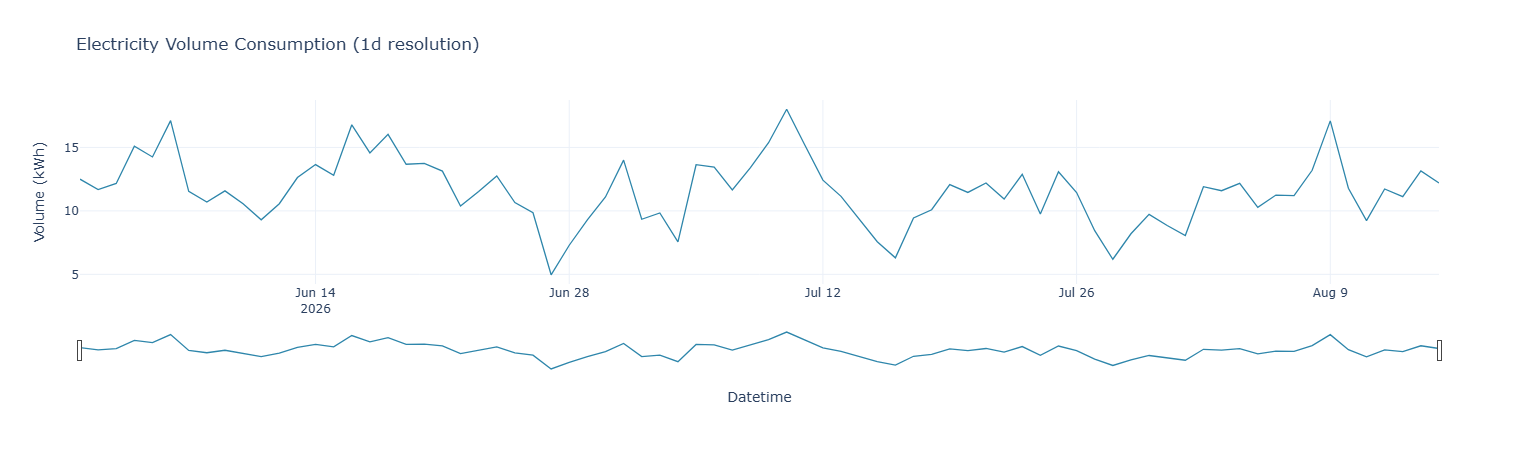

In [62]:
plot_timeseries(df, freq='1d') # freq='15min'

In [63]:
import pandas as pd
import plotly.graph_objects as go

def plot_daily_load_profile(
    df,
    time_resolution: str = '15min',   # '15min' or '1h'
    band: str = 'minmax',             # 'minmax' or 'p10p90'
    export_html: str | None = None
) -> go.Figure:
    """
    Average daily load profile: mean volume by time-of-day,
    with a shaded band showing variability (min/max or 10th/90th percentile).

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    time_resolution : '15min' or '1h' — granularity of the time-of-day axis
    band : 'minmax' or 'p10p90' — how the shaded variability band is computed
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])

    if time_resolution == '1h':
        d['time_of_day'] = d['datetime'].dt.hour
        x_label = 'Hour of Day'
    elif time_resolution == '15min':
        d['time_of_day'] = d['datetime'].dt.hour + d['datetime'].dt.minute / 60
        x_label = 'Time of Day (hour)'
    else:
        raise ValueError("time_resolution must be '15min' or '1h'")

    grouped = d.groupby('time_of_day')['volume']
    mean = grouped.mean()

    if band == 'minmax':
        lower, upper = grouped.min(), grouped.max()
        band_label = 'Min–Max'
    elif band == 'p10p90':
        lower, upper = grouped.quantile(0.10), grouped.quantile(0.90)
        band_label = 'P10–P90'
    else:
        raise ValueError("band must be 'minmax' or 'p10p90'")

    x = mean.index

    fig = go.Figure()

    # Shaded band (upper then lower, filled between)
    fig.add_trace(go.Scatter(
        x=list(x) + list(x[::-1]),
        y=list(upper) + list(lower[::-1]),
        fill='toself',
        fillcolor='rgba(46, 134, 171, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        name=band_label,
        showlegend=True
    ))

    # Mean line
    fig.add_trace(go.Scatter(
        x=x,
        y=mean,
        mode='lines+markers',
        name='Average',
        line=dict(width=2.5, color='#2E86AB'),
        marker=dict(size=4),
        hovertemplate='%{x}<br>Avg Volume: %{y:.3f}<extra></extra>'
    ))

    fig.update_layout(
        title=f'Average Daily Load Profile ({band_label} band)',
        xaxis_title=x_label,
        yaxis_title='Volume (kWh)',
        template='plotly_white',
        hovermode='x unified',
        height=450
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

In [132]:
import pandas as pd
import plotly.graph_objects as go

def plot_hourly_distribution(
    df,
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    day_type: str = 'all',             # 'all', 'weekday', 'weekend'
    show_points: str = 'outliers',     # 'outliers', 'all', 'suspectedoutliers', False
    export_html: str | None = None
) -> go.Figure:
    """
    Boxplot of 15-min interval volume distribution per hour of day,
    for spotting anomalies/outliers. Hover on individual points shows
    the exact date and weekday.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    day_type : 'all', 'weekday' (Mon–Fri), or 'weekend' (Sat–Sun)
    show_points : which points to overlay on the boxes — 'outliers', 'all',
                  'suspectedoutliers', or False (none)
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date
    d['hour'] = d['datetime'].dt.hour
    d['weekday_name'] = d['datetime'].dt.day_name()

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if day_type == 'weekday':
        d = d[d['datetime'].dt.weekday < 5]
    elif day_type == 'weekend':
        d = d[d['datetime'].dt.weekday >= 5]
    elif day_type != 'all':
        raise ValueError("day_type must be 'all', 'weekday', or 'weekend'")

    if d.empty:
        raise ValueError("No data left after applying filters.")

    # customdata: [date, weekday_name] per point, aligned with x/y
    customdata = d[['date', 'weekday_name']].astype(str).values

    fig = go.Figure()
    fig.add_trace(go.Box(
        x=d['hour'],
        y=d['volume'],
        customdata=customdata,
        boxpoints=show_points,
        marker=dict(color='#2E86AB', size=3, opacity=0.5),
        line=dict(color='#2E86AB'),
        fillcolor='rgba(46, 134, 171, 0.3)',
        hovertemplate=(
            'Date: %{customdata[0]} (%{customdata[1]})<br>'
            'Hour: %{x}<br>'
            'Volume: %{y:.3f}<extra></extra>'
        )
    ))

    fig.update_layout(
        title='Hourly Distribution of 15-min Volume (Boxplot)',
        xaxis_title='Hour of Day',
        yaxis_title='Volume (kWh)',
        template='plotly_white',
        xaxis=dict(tickmode='linear', tick0=0, dtick=1),
        height=500
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

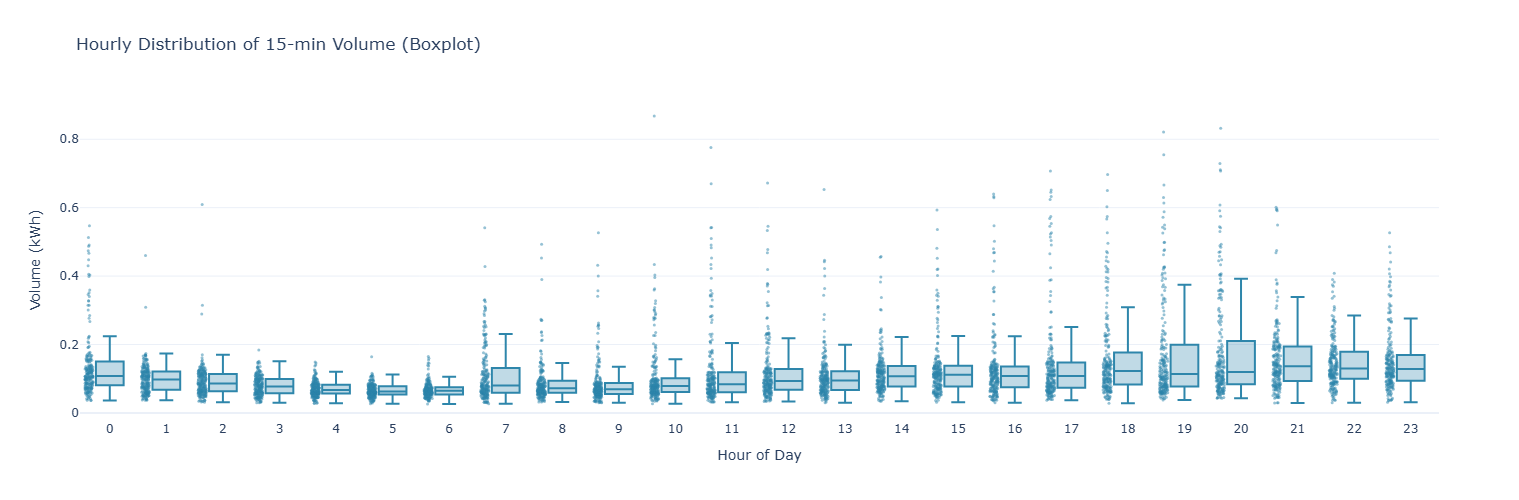

In [133]:
plot_hourly_distribution(df, day_type='weekday', show_points='all')

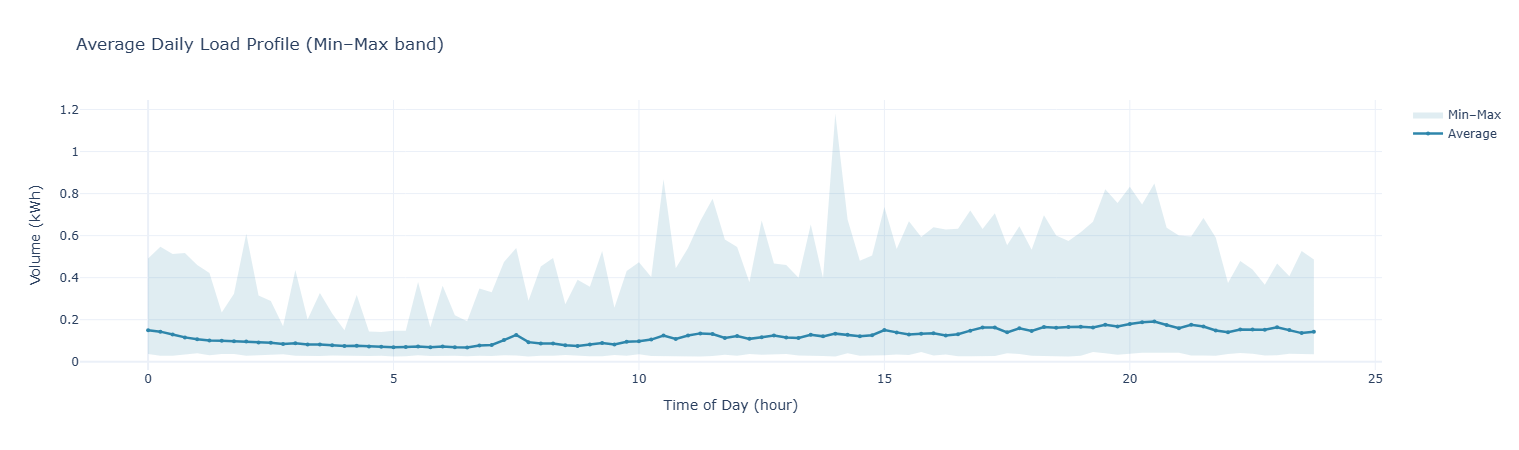

In [65]:
plot_daily_load_profile(df)
#plot_daily_load_profile(df, time_resolution='15min', band='minmax', export_html='daily_profile.html')

In [101]:
import pandas as pd
import plotly.graph_objects as go

def plot_heatmap(
    df,
    time_resolution: str = '1h',       # '15min' or '1h'
    agg: str = 'sum',                  # 'sum' or 'mean'
    x_tickangle: int = 280,
    y_bottom_to_top: bool = True,      # True: 00:00 at bottom, reading upward
    start_hour: int = 0,               # inclusive
    end_hour: int = 24,                # exclusive
    day_type: str = 'all',             # 'all', 'weekday', 'weekend'
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    export_html: str | None = None
) -> go.Figure:
    """
    Heatmap of electricity volume: time-of-day (y-axis) vs. date (x-axis).

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    time_resolution : '15min' or '1h' — granularity of the time-of-day axis
    agg : 'sum' or 'mean' — aggregation used when grouping into cells
    x_tickangle : rotation angle (degrees) for x-axis tick labels
    y_bottom_to_top : if True, earliest time is at the bottom, reading upward
    start_hour, end_hour : filter to this hour range [start_hour, end_hour)
    day_type : 'all', 'weekday' (Mon–Fri), or 'weekend' (Sat–Sun)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date
    d['hour'] = d['datetime'].dt.hour

    # --- filter: hour range ---
    d = d[(d['hour'] >= start_hour) & (d['hour'] < end_hour)]

    # --- filter: day type ---
    if day_type == 'weekday':
        d = d[d['datetime'].dt.weekday < 5]
    elif day_type == 'weekend':
        d = d[d['datetime'].dt.weekday >= 5]
    elif day_type != 'all':
        raise ValueError("day_type must be 'all', 'weekday', or 'weekend'")

    # --- filter: exclude specific dates ---
    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    # --- time-of-day bucket ---
    if time_resolution == '1h':
        d['time_of_day'] = d['hour']
        y_label = 'Hour of Day'
    elif time_resolution == '15min':
        d['time_of_day'] = d['datetime'].dt.strftime('%H:%M')
        y_label = 'Time of Day'
    else:
        raise ValueError("time_resolution must be '15min' or '1h'")

    pivot = d.pivot_table(
        index='time_of_day',
        columns='date',
        values='volume',
        aggfunc=agg
    )
    pivot = pivot.sort_index(ascending=y_bottom_to_top)

    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=[str(c) for c in pivot.columns],
        y=[str(i) for i in pivot.index],
        colorscale='YlOrRd',
        colorbar=dict(title='Volume (kWh)'),
        hovertemplate='Date: %{x}<br>Time: %{y}<br>Volume: %{z:.3f}<extra></extra>'
    ))

    fig.update_layout(
        title=f'Electricity Volume Heatmap ({agg} per {time_resolution} bucket)',
        xaxis_title='Date',
        yaxis_title=y_label,
        template='plotly_white',
        height=500,
        xaxis=dict(type='category', tickangle=x_tickangle),
        yaxis=dict(type='category')
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

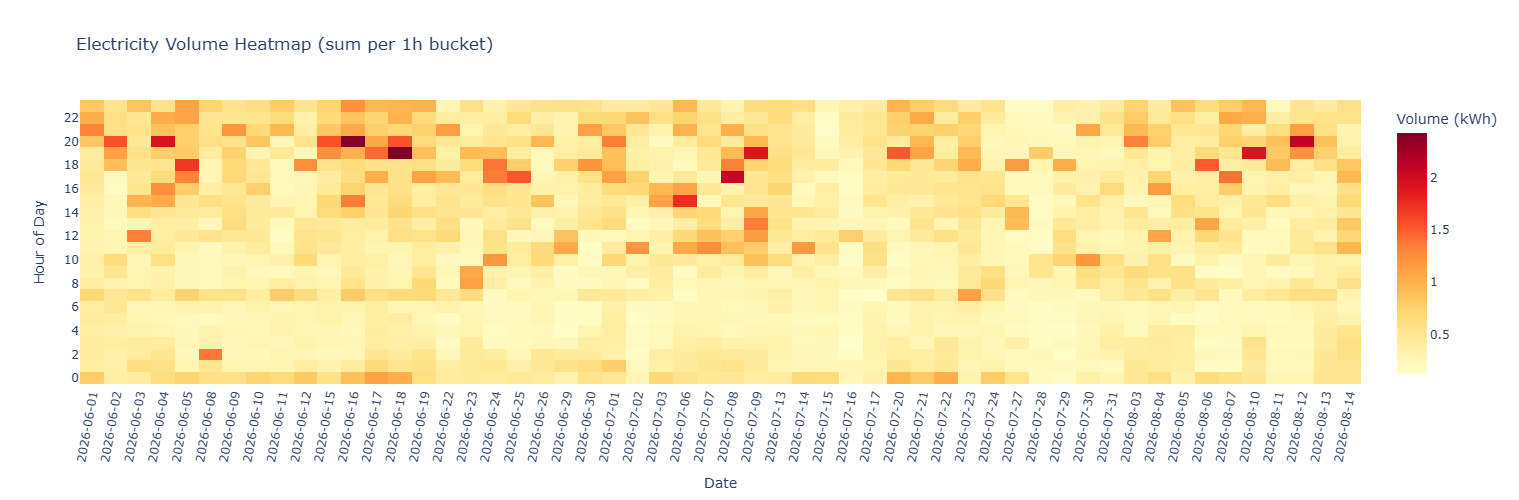

In [103]:
 plot_heatmap(df, exclude_days= ['2026-07-10'], day_type= 'weekday') #, export_html='heatmap.html', exclude_days=['2026-08-15', '2026-07-10'

In [108]:
import pandas as pd
import plotly.graph_objects as go

def plot_day_of_week_pattern(
    df,
    agg: str = 'mean',                 # 'mean' or 'sum'
    start_hour: int = 0,               # inclusive
    end_hour: int = 24,                # exclusive
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    bargap: float = 0.4,               # spacing between bars (0-1), higher = more gap
    log_scale: bool = False,           # log scale for y-axis
    export_html: str | None = None
) -> go.Figure:
    """
    Bar chart of electricity volume aggregated by day of week (Mon–Sun).

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    agg : 'mean' (typical volume per weekday) or 'sum' (total volume per weekday, across all weeks)
    start_hour, end_hour : filter to this hour range [start_hour, end_hour)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    bargap : gap between bars as a fraction of bar width (0 = touching, closer to 1 = thin bars)
    log_scale : if True, y-axis uses log scale
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date
    d['hour'] = d['datetime'].dt.hour

    d = d[(d['hour'] >= start_hour) & (d['hour'] < end_hour)]

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    d['weekday_name'] = d['datetime'].dt.day_name()

    if agg == 'mean':
        grouped = d.groupby('weekday_name')['volume'].mean().reindex(weekday_order)
        y_label = 'Average Volume (kWh)'
    elif agg == 'sum':
        daily_totals = d.groupby(['date', 'weekday_name'])['volume'].sum().reset_index()
        grouped = daily_totals.groupby('weekday_name')['volume'].mean().reindex(weekday_order)
        y_label = 'Average Daily Total Volume (kWh)'
    else:
        raise ValueError("agg must be 'mean' or 'sum'")

    colors = ['#2E86AB'] * 5 + ['#E76F51'] * 2  # highlight weekends

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=grouped.index,
        y=grouped.values,
        marker_color=colors,
        hovertemplate='%{x}<br>Volume: %{y:.3f}<extra></extra>'
    ))

    fig.update_layout(
        title='Electricity Volume by Day of Week',
        xaxis_title='Day of Week',
        yaxis_title=y_label,
        yaxis_type='log' if log_scale else 'linear',
        template='plotly_white',
        bargap=bargap,
        height=450
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

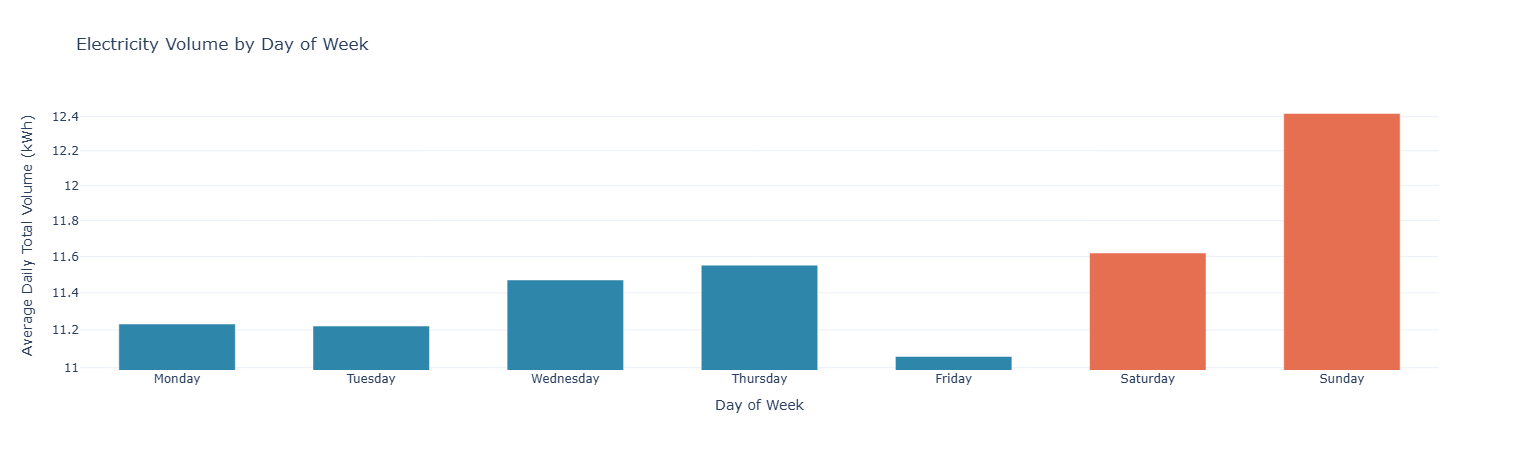

In [111]:
plot_day_of_week_pattern(df, agg='sum', log_scale=True, exclude_days= ['2026-07-10'])

In [112]:
import pandas as pd
import plotly.graph_objects as go

def plot_daily_totals(
    df,
    exclude_days: list | None = None,   # e.g. ['2026-08-15', '2026-07-10']
    rolling_window: int | None = 7,     # e.g. 7 for a 7-day rolling average overlay; None to disable
    bargap: float = 0.2,
    log_scale: bool = False,
    export_html: str | None = None
) -> go.Figure:
    """
    Bar chart of total electricity volume per day, with optional rolling average overlay.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    rolling_window : window size (in days) for rolling average line; None disables it
    bargap : gap between bars as a fraction of bar width
    log_scale : if True, y-axis uses log scale
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    daily = d.groupby('date')['volume'].sum().reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.sort_values('date')

    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=daily['date'],
        y=daily['volume'],
        name='Daily Total',
        marker_color='#2E86AB',
        hovertemplate='%{x|%Y-%m-%d}<br>Total Volume: %{y:.3f}<extra></extra>'
    ))

    if rolling_window:
        daily['rolling'] = daily['volume'].rolling(window=rolling_window, min_periods=1).mean()
        fig.add_trace(go.Scatter(
            x=daily['date'],
            y=daily['rolling'],
            mode='lines',
            name=f'{rolling_window}-Day Rolling Avg',
            line=dict(width=2.5, color='#E76F51'),
            hovertemplate='%{x|%Y-%m-%d}<br>Rolling Avg: %{y:.3f}<extra></extra>'
        ))

    fig.update_layout(
        title='Daily Total Electricity Volume',
        xaxis_title='Date',
        yaxis_title='Total Volume (kWh)',
        yaxis_type='log' if log_scale else 'linear',
        template='plotly_white',
        hovermode='x unified',
        bargap=bargap,
        height=450,
        xaxis=dict(rangeslider=dict(visible=True), type='date')
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

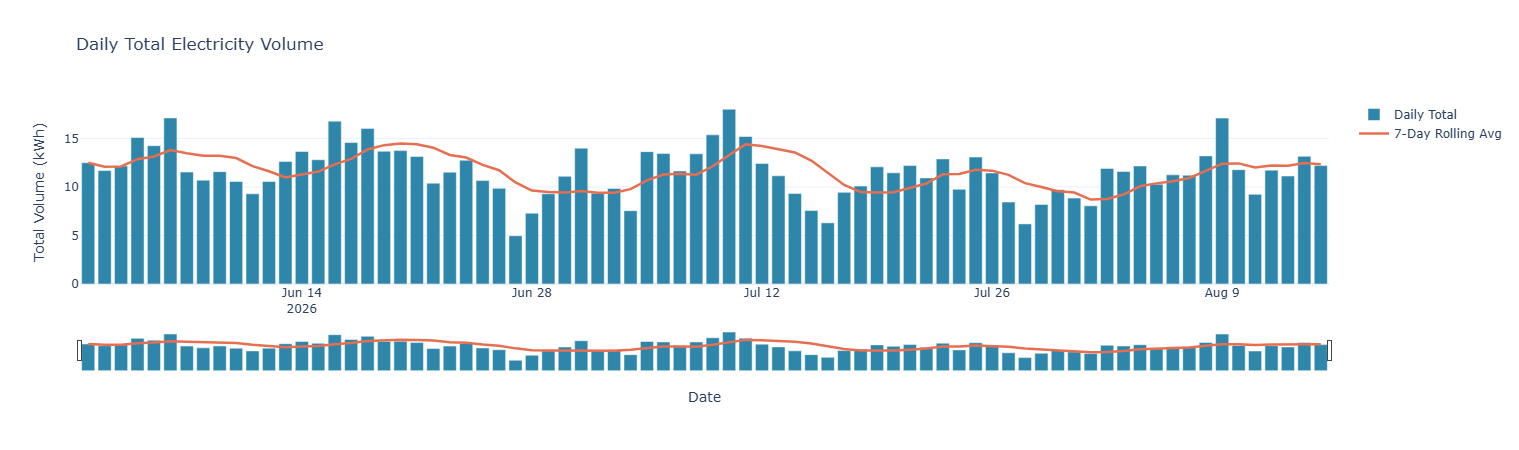

In [113]:
 plot_daily_totals(df, rolling_window=7)

In [114]:
import pandas as pd
import plotly.graph_objects as go

def plot_distribution(
    df,
    nbins: int = 50,                   # number of histogram bins
    split_by: str | None = None,       # None, 'day_type' (weekday/weekend), or 'weekday' (per weekday name)
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    log_scale: bool = False,           # log scale for y-axis (count)
    export_html: str | None = None
) -> go.Figure:
    """
    Histogram of electricity volume values (per interval), optionally split
    by weekday/weekend or by individual weekday.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    nbins : number of bins in the histogram
    split_by : None (single histogram), 'day_type' (weekday vs weekend overlay),
               or 'weekday' (one trace per day name)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    log_scale : if True, y-axis (count) uses log scale
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    fig = go.Figure()

    if split_by is None:
        fig.add_trace(go.Histogram(
            x=d['volume'],
            nbinsx=nbins,
            marker_color='#2E86AB',
            name='Volume',
            hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
        ))

    elif split_by == 'day_type':
        d['day_type'] = d['datetime'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
        colors = {'Weekday': '#2E86AB', 'Weekend': '#E76F51'}
        for label, group in d.groupby('day_type'):
            fig.add_trace(go.Histogram(
                x=group['volume'],
                nbinsx=nbins,
                name=label,
                marker_color=colors[label],
                opacity=0.6,
                hovertemplate=f'{label}<br>Range: %{{x}}<br>Count: %{{y}}<extra></extra>'
            ))
        fig.update_layout(barmode='overlay')

    elif split_by == 'weekday':
        weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        d['weekday_name'] = d['datetime'].dt.day_name()
        for label in weekday_order:
            group = d[d['weekday_name'] == label]
            if group.empty:
                continue
            fig.add_trace(go.Histogram(
                x=group['volume'],
                nbinsx=nbins,
                name=label,
                opacity=0.5,
                hovertemplate=f'{label}<br>Range: %{{x}}<br>Count: %{{y}}<extra></extra>'
            ))
        fig.update_layout(barmode='overlay')

    else:
        raise ValueError("split_by must be None, 'day_type', or 'weekday'")

    fig.update_layout(
        title='Distribution of Electricity Volume (per interval)',
        xaxis_title='Volume (kWh)',
        yaxis_title='Count',
        yaxis_type='log' if log_scale else 'linear',
        template='plotly_white',
        height=450
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

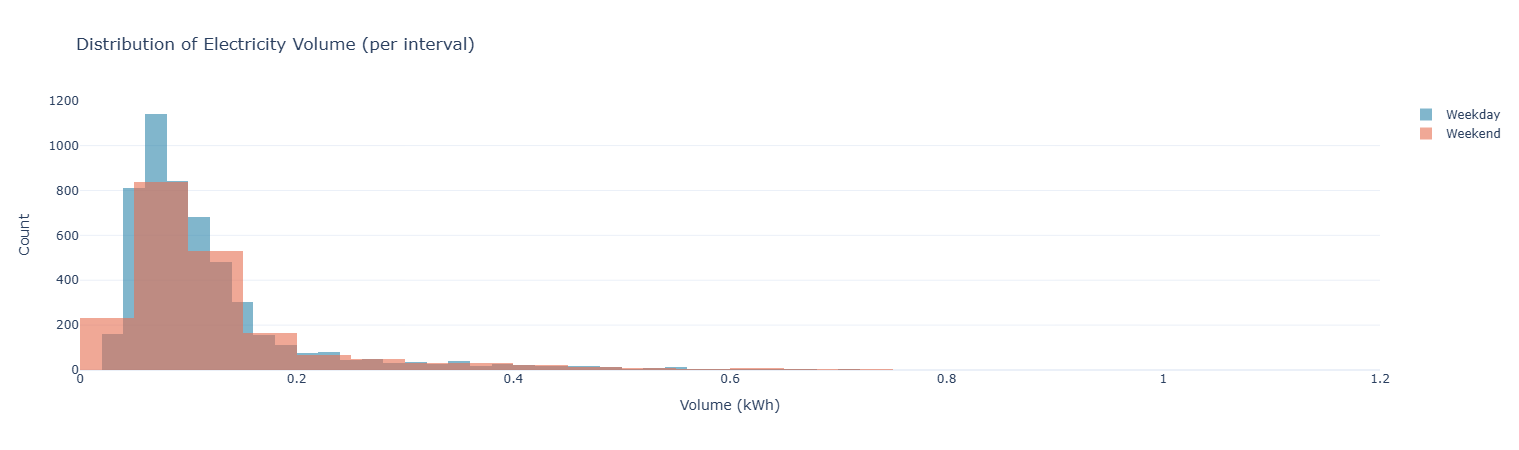

In [115]:
plot_distribution(df, nbins=50, split_by='day_type')

In [121]:
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc

def plot_cumulative_sum(
    df,
    period: str = 'daily',             # 'daily', 'weekly', or 'monthly'
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    max_periods: int | None = None,    # limit number of periods shown
    sort_by: str = 'recent',           # 'recent', 'max_cumsum', or 'min_cumsum'
    export_html: str | None = None
) -> go.Figure:
    """
    Line chart of cumulative volume, resetting to 0 at the start of each period.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    period : 'daily' (resets each day), 'weekly' (resets each week, Mon start),
             or 'monthly' (resets each month)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    max_periods : if set, only plot N periods (selection controlled by sort_by)
    sort_by : 'recent' (last N periods in time), 'max_cumsum' (top N by final
              cumulative total), 'min_cumsum' (bottom N by final cumulative total)
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    d = d.sort_values('datetime')

    # --- assign period group + elapsed time within period ---
    if period == 'daily':
        d['period_id'] = d['datetime'].dt.date.astype(str)
        period_start = d.groupby('period_id')['datetime'].transform('min')
        d['elapsed_hours'] = (d['datetime'] - period_start).dt.total_seconds() / 3600
        x_label = 'Elapsed Hours (since 00:00)'
    elif period == 'weekly':
        iso = d['datetime'].dt.isocalendar()
        d['period_id'] = iso['year'].astype(str) + '-W' + iso['week'].astype(str).str.zfill(2)
        period_start = d.groupby('period_id')['datetime'].transform('min')
        d['elapsed_hours'] = (d['datetime'] - period_start).dt.total_seconds() / 3600
        x_label = 'Elapsed Hours (since start of week)'
    elif period == 'monthly':
        d['period_id'] = d['datetime'].dt.strftime('%Y-%m')
        period_start = d.groupby('period_id')['datetime'].transform('min')
        d['elapsed_hours'] = (d['datetime'] - period_start).dt.total_seconds() / 3600
        x_label = 'Elapsed Hours (since start of month)'
    else:
        raise ValueError("period must be 'daily', 'weekly', or 'monthly'")

    # --- cumulative sum within each period ---
    d['cumsum'] = d.groupby('period_id')['volume'].cumsum()

    # --- select which periods to show ---
    if sort_by == 'recent':
        period_ids = list(d['period_id'].drop_duplicates())
        if max_periods:
            period_ids = period_ids[-max_periods:]
    elif sort_by in ('max_cumsum', 'min_cumsum'):
        totals = d.groupby('period_id')['cumsum'].max().sort_values(
            ascending=(sort_by == 'min_cumsum')
        )
        period_ids = list(totals.index)
        if max_periods:
            period_ids = period_ids[:max_periods]
    else:
        raise ValueError("sort_by must be 'recent', 'max_cumsum', or 'min_cumsum'")

    d = d[d['period_id'].isin(period_ids)]

    # --- plot one line per period ---
    colors = pc.sample_colorscale('Viridis', [i / max(len(period_ids) - 1, 1) for i in range(len(period_ids))])

    fig = go.Figure()
    for pid, color in zip(period_ids, colors):
        group = d[d['period_id'] == pid]
        fig.add_trace(go.Scatter(
            x=group['elapsed_hours'],
            y=group['cumsum'],
            mode='lines',
            name=pid,
            line=dict(width=1.5, color=color),
            hovertemplate=f'{pid}<br>Elapsed: %{{x:.2f}}h<br>Cumulative: %{{y:.3f}}<extra></extra>'
        ))

    fig.update_layout(
        title=f'Cumulative Volume by {period.capitalize()} Period ({sort_by})',
        xaxis_title=x_label,
        yaxis_title='Cumulative Volume (kWh)',
        template='plotly_white',
        hovermode='closest',
        height=500,
        legend=dict(title=period.capitalize())
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

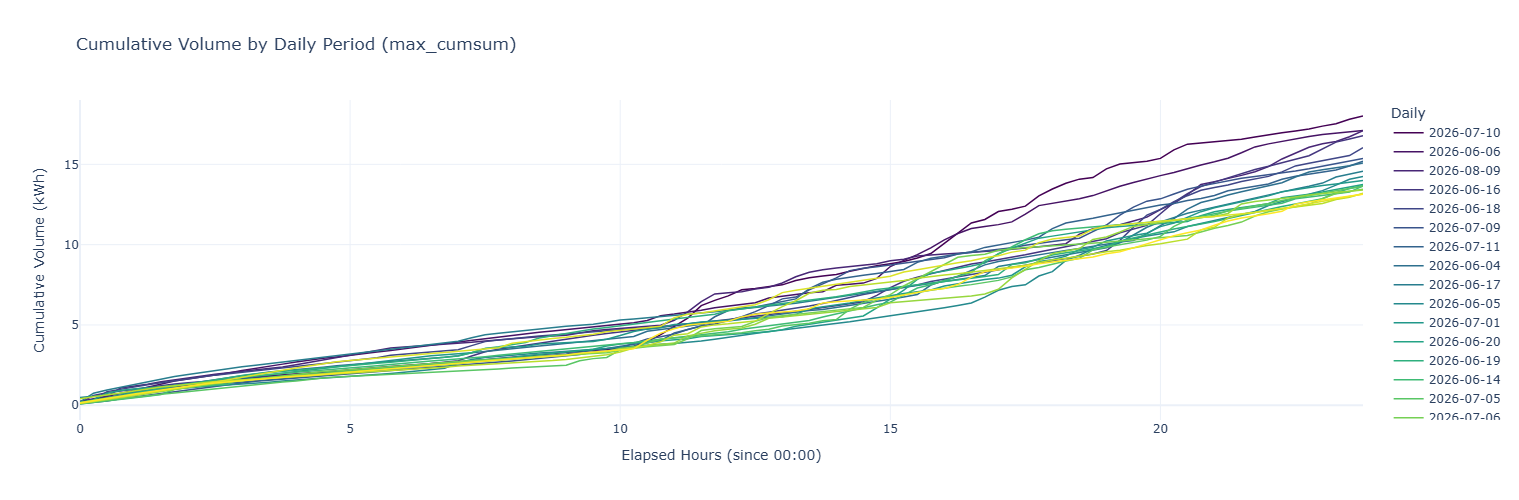

In [123]:
plot_cumulative_sum(df, period='daily', sort_by='max_cumsum', max_periods=20)

In [126]:
import pandas as pd
import plotly.graph_objects as go

def table_top_consumption_days(
    df,
    top_n: int = 10,
    order: str = 'highest',            # 'highest' or 'lowest'
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    export_html: str | None = None
) -> go.Figure:
    """
    Table of top (or bottom) consumption days, with weekday and comparison to average.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    top_n : number of days to show
    order : 'highest' (top consuming days) or 'lowest' (bottom consuming days)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    # --- daily totals ---
    daily = d.groupby('date')['volume'].sum().reset_index()
    daily['weekday'] = pd.to_datetime(daily['date']).dt.day_name()

    avg_total = daily['volume'].mean()
    daily['vs_avg_pct'] = (daily['volume'] / avg_total - 1) * 100

    # --- sort & select ---
    ascending = (order == 'lowest')
    daily = daily.sort_values('volume', ascending=ascending).head(top_n)
    daily = daily.reset_index(drop=True)
    daily.insert(0, 'rank', daily.index + 1)

    # --- color-code the vs-average column (green = above avg, red = below) ---
    cell_colors = ['#e8f4ea' if v >= 0 else '#fde8e8' for v in daily['vs_avg_pct']]

    fig = go.Figure(data=[go.Table(
        columnwidth=[40, 90, 100, 100, 110],
        header=dict(
            values=['Rank', 'Date', 'Weekday', 'Total Volume (kWh)', 'vs. Average'],
            fill_color='#2E86AB',
            font=dict(color='white', size=13),
            align='center',
            height=32
        ),
        cells=dict(
            values=[
                daily['rank'],
                daily['date'].astype(str),
                daily['weekday'],
                daily['volume'].round(3),
                daily['vs_avg_pct'].apply(lambda x: f'{x:+.1f}%')
            ],
            fill_color=[['white'] * len(daily)] * 3 + [['white'] * len(daily)] + [cell_colors],
            align='center',
            height=28
        )
    )])

    fig.update_layout(
        title=f'{"Top" if order == "highest" else "Bottom"} {top_n} Consumption Days '
              f'(Average: {avg_total:.3f} kWh/day)',
        height=90 + 32 * top_n,
        margin=dict(t=60, b=10, l=10, r=10)
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

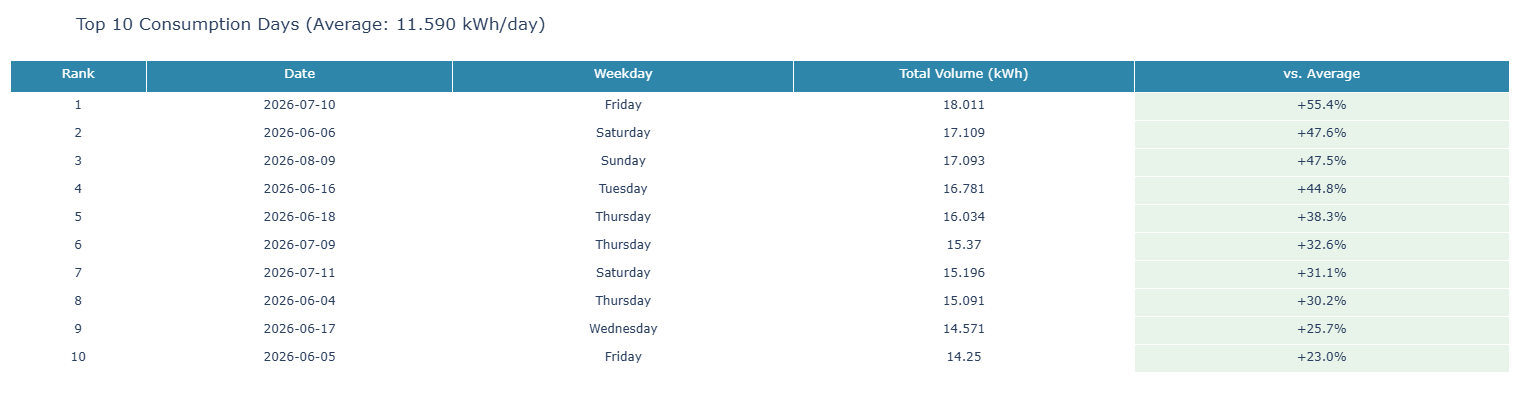

In [127]:
table_top_consumption_days(df, top_n=10, order='highest')

In [128]:
import pandas as pd
import plotly.graph_objects as go

def table_top_consumption_days(
    df,
    top_n: int = 10,
    order: str = 'highest',            # 'highest' or 'lowest'
    exclude_days: list | None = None,  # e.g. ['2026-08-15', '2026-07-10']
    export_html: str | None = None
) -> go.Figure:
    """
    Table of top (or bottom) consumption days, with weekday, comparison to
    average daily total, and that day's peak hour vs. the typical average for that hour.

    Parameters
    ----------
    df : DataFrame with columns ['datetime', 'volume']
    top_n : number of days to show
    order : 'highest' (top consuming days) or 'lowest' (bottom consuming days)
    exclude_days : list of specific dates to exclude, e.g. ['2026-08-15', '2026-07-10']
    export_html : optional path to save standalone HTML
    """
    d = df.copy()
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['date'] = d['datetime'].dt.date
    d['hour'] = d['datetime'].dt.hour

    if exclude_days:
        exclude_dates = {pd.to_datetime(e).date() for e in exclude_days}
        d = d[~d['date'].isin(exclude_dates)]

    if d.empty:
        raise ValueError("No data left after applying filters.")

    # --- daily totals ---
    daily = d.groupby('date')['volume'].sum().reset_index()
    daily['weekday'] = pd.to_datetime(daily['date']).dt.day_name()

    avg_total = daily['volume'].mean()
    daily['vs_avg_pct'] = (daily['volume'] / avg_total - 1) * 100

    # --- hourly totals per day (sum if multiple 15-min intervals fall in the hour) ---
    hourly_per_day = d.groupby(['date', 'hour'])['volume'].sum().reset_index()

    # --- peak hour per day: the hour with max volume that day ---
    peak_idx = hourly_per_day.groupby('date')['volume'].idxmax()
    peak_hours = hourly_per_day.loc[peak_idx].rename(columns={'hour': 'peak_hour', 'volume': 'peak_hour_volume'})

    # --- typical average volume for each hour-of-day, across all days ---
    hour_avg = hourly_per_day.groupby('hour')['volume'].mean().rename('hour_avg_volume')

    peak_hours = peak_hours.merge(hour_avg, left_on='peak_hour', right_index=True, how='left')
    peak_hours['peak_vs_hour_avg_pct'] = (
        peak_hours['peak_hour_volume'] / peak_hours['hour_avg_volume'] - 1
    ) * 100

    daily = daily.merge(peak_hours[['date', 'peak_hour', 'peak_hour_volume', 'hour_avg_volume', 'peak_vs_hour_avg_pct']],
                         on='date', how='left')

    # --- sort & select ---
    ascending = (order == 'lowest')
    daily = daily.sort_values('volume', ascending=ascending).head(top_n)
    daily = daily.reset_index(drop=True)
    daily.insert(0, 'rank', daily.index + 1)

    # --- color-code vs-average columns ---
    day_avg_colors = ['#e8f4ea' if v >= 0 else '#fde8e8' for v in daily['vs_avg_pct']]
    hour_avg_colors = ['#e8f4ea' if v >= 0 else '#fde8e8' for v in daily['peak_vs_hour_avg_pct']]

    fig = go.Figure(data=[go.Table(
        columnwidth=[35, 85, 90, 100, 90, 75, 95, 105, 100],
        header=dict(
            values=['Rank', 'Date', 'Weekday', 'Daily Total (kWh)', 'vs. Daily Avg',
                    'Peak Hour', 'Peak Volume (kWh)', 'Typical Avg for that Hour', 'Peak vs. Hour Avg'],
            fill_color='#2E86AB',
            font=dict(color='white', size=12),
            align='center',
            height=36
        ),
        cells=dict(
            values=[
                daily['rank'],
                daily['date'].astype(str),
                daily['weekday'],
                daily['volume'].round(3),
                daily['vs_avg_pct'].apply(lambda x: f'{x:+.1f}%'),
                daily['peak_hour'].apply(lambda h: f'{h:02d}:00'),
                daily['peak_hour_volume'].round(3),
                daily['hour_avg_volume'].round(3),
                daily['peak_vs_hour_avg_pct'].apply(lambda x: f'{x:+.1f}%')
            ],
            fill_color=[
                ['white'] * len(daily),  # rank
                ['white'] * len(daily),  # date
                ['white'] * len(daily),  # weekday
                ['white'] * len(daily),  # daily total
                day_avg_colors,          # vs daily avg
                ['white'] * len(daily),  # peak hour
                ['white'] * len(daily),  # peak volume
                ['white'] * len(daily),  # typical avg for hour
                hour_avg_colors          # peak vs hour avg
            ],
            align='center',
            height=28
        )
    )])

    fig.update_layout(
        title=f'{"Top" if order == "highest" else "Bottom"} {top_n} Consumption Days '
              f'(Average daily total: {avg_total:.3f} kWh)',
        height=100 + 30 * top_n,
        margin=dict(t=60, b=10, l=10, r=10)
    )

    if export_html:
        fig.write_html(export_html, include_plotlyjs='cdn')

    return fig

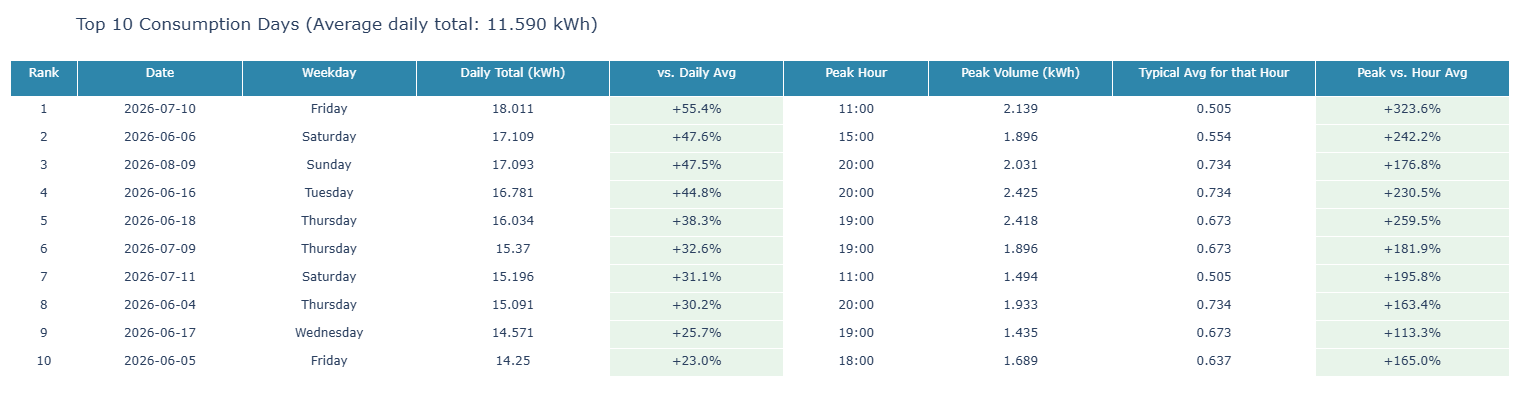

In [129]:
table_top_consumption_days(df, top_n=10, order='highest')